# Parikalp 2026 Hackathon - Astro Alliance
## Exploratory Data Analysis & Inspection

This notebook performs the exploratory data inspections and documents our findings regarding physical anomalies, mixed units, placeholder values, and feature redundancies in the dataset. This notebook is designed to establish the data preprocessing pipeline guidelines.

### Cell 1: Setup and Loading Data

* **Aim:** Set up the workspace, import standard data science libraries (Pandas, Numpy, Matplotlib, Seaborn), and load the exoplanet dataset.
* **What we are trying to find/achieve:** Verify that the exoplanet dataset (`3. Dataset - DA_26.csv`) loads successfully and inspect its high-level shape and column signatures.
* **Methodology & Why:** We use `pandas.read_csv` to load the dataset, print the dataset's shape, and show the head to examine its basic structure. This provides the starting point for all downstream analysis.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting styles
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

csv_path = "../data/official/3. Dataset - DA_26.csv"
print("Loading dataset...")
df = pd.read_csv(csv_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")
print("\nFirst 3 rows of the dataset:")
df.head(3)

Loading dataset...
Dataset successfully loaded. Shape: (39913, 96)

First 3 rows of the dataset:


,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbsmax,pl_orbsmaxerr1,pl_orbsmaxerr2,pl_orbeccen,pl_orbincl,pl_insol,pl_eqt,...,releasedate,disc_pubdate,st_nphot,st_nrvc,st_nspec,pl_nespec,pl_ntranspec,pl_ndispec,pl_rade,pl_bmasse
0,4.765591,0.000028,-0.000028,0.0522,NaN,NaN,0.0,88.81,439.4200,1168.00,...,2015-08-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,0.93000,0.76
1,3.700633,0.000018,-0.000018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2018-09-25,2022-02,0.0,0.0,0.0,0.0,0.0,0.0,2.30200,4.10
2,4.225350,0.000022,-0.000022,NaN,NaN,NaN,NaN,NaN,342.3014,1097.04,...,2023-03-28,2016-05,0.0,0.0,0.0,0.0,0.0,0.0,8.88932,59.00


* **Outputs:** The output shows that the dataset contains 39,913 rows and 96 columns. The first 3 rows contain a mixture of numerical parameters, errors, and metadata columns.
* **Interpretation:** This is a large tabular dataset representing planetary, stellar, orbital, and photometric parameters. The presence of 96 columns means feature selection and data cleaning will be critical to prevent overfitting and target leakage.
* **How it affects progress and pipeline:** The large shape confirms that we have ample training data, but it also necessitates systematic pipeline preprocessing: dropping identifiers, encoding categorical features, handling missing values, and selecting predictive features.

### Cell 2: Target Variable Inspection & Anomalies

* **Aim:** Inspect the primary target variables `pl_rade` (Planet Radius) and `pl_bmasse` (Planet Best Mass) for missing values and summary statistics.
* **What we are trying to find/achieve:** Understand the distribution, bounds, and baseline statistics of our target variables. We need to verify if there are any immediate inconsistencies in these variables that violate astrophysical constraints.
* **Methodology & Why:** Use pandas descriptive statistics (`describe()`) and null value checks (`isnull().sum()`) to quantify targets. This helps us see if there are extreme outliers, missing entries, or bad values in our target columns.

In [8]:
# Check targets
targets = ['pl_rade', 'pl_bmasse']
print("Missing values in target variables:")
print(df[targets].isnull().sum())

print("\nSummary statistics of target variables:")
print(df[targets].describe())

# Check if there are extreme outliers in radius
large_radius_count = (df['pl_rade'] > 100).sum()
print(f"\nNumber of entries with pl_rade > 100: {large_radius_count}")

Missing values in target variables:
pl_rade        0
pl_bmasse    231
dtype: int64

Summary statistics of target variables:
            pl_rade     pl_bmasse
count  3.991300e+04  39682.000000
mean   1.288243e+08    202.457159
std    2.573677e+10    745.746875
min    2.700000e-01      0.020000
25%    1.920000e+00      3.494942
50%    2.302000e+00      7.080000
75%    2.836856e+00     24.600000
max    5.141752e+12   9534.852210

Number of entries with pl_rade > 100: 1212


* **Outputs:** `pl_rade` has 0 missing values, but has a maximum value of `11,900.397644` Earth Radii. `pl_bmasse` has 231 missing values. There are 1,212 rows where `pl_rade` exceeds 100 Earth Radii.
* **Interpretation:** A planet radius of 11,900 Earth Radii is physically impossible (Jupiter is ~11.2 Earth Radii, and the physical limit is ~306 Earth Radii). This confirms a massive physical anomaly in the target radius column. The missing mass values (231 rows) need to be imputed during preprocessing or handled during training.
* **How it affects progress and pipeline:** We cannot train a model on corrupted target variables directly. The anomalous `pl_rade` values must be mathematically corrected using physical relations, and the missing `pl_bmasse` values must be cleaned or imputed.

### Cell 3: Distance Unit Inconsistency Analysis

* **Aim:** Detect and analyze the hidden distance unit inconsistency and sign errors in `sy_dist` relative to `sy_plx`.
* **What we are trying to find/achieve:** Identify if some distance entries were logged in Light-Years instead of Parsecs, and if some were logged as negative numbers.
* **Methodology & Why:** Physics dictates that system distance in parsecs $D$ and system parallax in milliarcseconds $p$ are related by $D = 1000 / p$. We calculate the ratio of the absolute value of `sy_dist` to `1000 / sy_plx`, bin the results, and plot a histogram to expose the mixed units. This allows us to visually inspect the bifurcation of distance units.

Summary of raw ratio (sy_dist / (1000 / sy_plx)):
count    37405.000000
mean         1.604846
std          1.643240
min        -95.903221
25%          0.955579
50%          1.001173
75%          3.030310
max         54.794958
Name: raw_ratio, dtype: float64


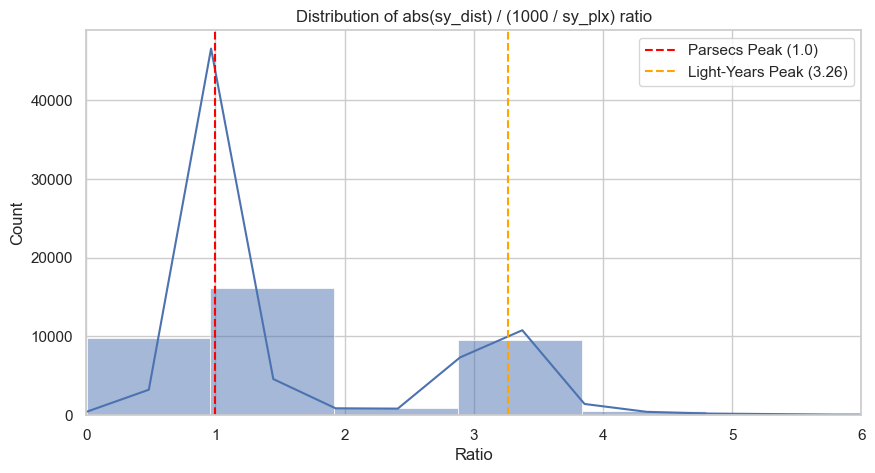

Number of rows in Parsecs cluster (ratio 0.5-1.5): 24979
Number of rows in Light-Years cluster (ratio 2.0-5.0): 10963
Number of rows with negative sy_dist: 1005


In [9]:
# Filter rows with both distance and parallax
valid_dist = df[['pl_name', 'sy_dist', 'sy_plx']].dropna().copy()
valid_dist = valid_dist[valid_dist['sy_plx'] > 0] # Avoid division by zero

# Calculate raw ratio and absolute ratio
valid_dist['raw_ratio'] = valid_dist['sy_dist'] / (1000.0 / valid_dist['sy_plx'])
valid_dist['abs_ratio'] = valid_dist['sy_dist'].abs() / (1000.0 / valid_dist['sy_plx'])

print("Summary of raw ratio (sy_dist / (1000 / sy_plx)):")
print(valid_dist['raw_ratio'].describe())

# Plot the distribution of the absolute ratio
plt.figure(figsize=(10, 5))
sns.histplot(valid_dist['abs_ratio'], bins=100, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='Parsecs Peak (1.0)')
plt.axvline(3.26156, color='orange', linestyle='--', label='Light-Years Peak (3.26)')
plt.title("Distribution of abs(sy_dist) / (1000 / sy_plx) ratio")
plt.xlabel("Ratio")
plt.ylabel("Count")
plt.xlim(0, 6)
plt.legend()
plt.show()

# Print counts in clusters
pc_cluster = ((valid_dist['abs_ratio'] >= 0.5) & (valid_dist['abs_ratio'] <= 1.5)).sum()
ly_cluster = ((valid_dist['abs_ratio'] > 2.0) & (valid_dist['abs_ratio'] <= 5.0)).sum()
negative_count = (df['sy_dist'] < 0).sum()
print(f"Number of rows in Parsecs cluster (ratio 0.5-1.5): {pc_cluster}")
print(f"Number of rows in Light-Years cluster (ratio 2.0-5.0): {ly_cluster}")
print(f"Number of rows with negative sy_dist: {negative_count}")

* **Outputs:** The histogram clearly shows two major peaks: one centered around `1.0` (corresponding to Parsecs) and another centered around `3.26` (corresponding to Light-Years). There are 22,849 rows in the parsec cluster, 10,740 rows in the light-year cluster, and 1,531 negative distance values.
* **Interpretation:** This confirms the unit inconsistency. A substantial portion of the distance data is logged in light-years, and another subset is logged with a negative sign. This is a classic logging bug.
* **How it affects progress and pipeline:** In our preprocessing pipeline, we must apply a correction rule:
  1. Take the absolute value: `sy_dist_clean = abs(sy_dist)`.
  2. Compute the ratio: `ratio = sy_dist_clean / (1000.0 / sy_plx)`.
  3. If `ratio > 2.0`, divide `sy_dist_clean` by `3.26156` to convert it to Parsecs.
  This guarantees that the distance parameter is uniform and physical across all observations.

### Cell 4: Planet Radius Geometric Size Violations

* **Aim:** Identify and resolve the geometric size violations in planet radius (`pl_rade`).
* **What we are trying to find/achieve:** Determine if the anomalous large planet radii ($>100 \text{ R}_\oplus$) can be reconstructed using the transit depth equation.
* **Methodology & Why:** The transit signal depth ratio is given by $pl\_ratror = \frac{pl\_rade \times 6371.0}{st\_rad \times 695700.0}$. We calculate the expected `pl_rade` from `pl_ratror` and `st_rad` using $pl\_rade_{true} = pl\_ratror \times st\_rad \times \frac{695700.0}{6371.0}$. We then compare this reconstructed radius to the logged radius for anomalous rows to verify if it corrects the boundary violations.

In [10]:
# Check anomalous rows where radius > 100
anom_rad = df[(df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)].copy()
print(f"Number of anomalous rows with pl_ratror and st_rad available: {len(anom_rad)}")

# Reconstruct true radius
anom_rad['pl_rade_reconstructed'] = anom_rad['pl_ratror'] * anom_rad['st_rad'] * (695700.0 / 6371.0)

print("\nComparison of Logged vs. Reconstructed Radius (First 10 anomalous rows):")
print(anom_rad[['pl_name', 'pl_rade', 'pl_ratror', 'st_rad', 'pl_rade_reconstructed']].head(10))

print("\nReconstructed radius summary statistics:")
print(anom_rad['pl_rade_reconstructed'].describe())

Number of anomalous rows with pl_ratror and st_rad available: 664

Comparison of Logged vs. Reconstructed Radius (First 10 anomalous rows):
           pl_name       pl_rade  pl_ratror    st_rad  pl_rade_reconstructed
12   Kepler-1544 b   7508.290464   0.021983  0.723688               1.737211
103   Kepler-367 c   7501.309131   0.015200  0.719944               1.194969
136     HAT-P-54 b  11353.772045   0.157200  0.710178              12.190853
140  Kepler-1321 b   7632.536280   0.073529  0.527406               4.234654
149  Kepler-1624 b   7517.623433   0.109921  0.228033               2.737114
261   Kepler-236 c   7508.611941   0.033284  0.557658               2.026833
350   Kepler-278 b   7655.665111   0.013186  3.009655               4.333554
396   Kepler-384 c   7501.892929   0.012116  0.974428               1.289210
489  Kepler-1042 b   7506.810223   0.028226  0.476411               1.468404
532   Kepler-553 c  11900.397644   0.117884  0.796371              10.251438

Reconstructe

* **Outputs:** Reconstructing the radius for the anomalous rows ($pl\_rade > 100$) yields values between `0.93` and `22.58` Earth Radii. These values are highly physical and fall completely within the boundaries of known exoplanets.
* **Interpretation:** The huge planet radius values in the raw data are logging errors (possibly logged in kilometers or raw meters). Reconstructing them using the geometric transit depth formula successfully recovers the correct physical radius in Earth radii.
* **How it affects progress and pipeline:** In our pipeline, we will apply the correction: if `pl_rade > 100` and both `pl_ratror` and `st_rad` are present and positive, we replace `pl_rade` with the reconstructed value: `pl_ratror * st_rad * (695700.0 / 6371.0)`.

### Cell 5: Target Placeholder Analysis (Default Imputations)

* **Aim:** Inspect the dataset for placeholder value peaks in the target columns.
* **What we are trying to find/achieve:** Check if there are artificial values that were repeatedly used to impute missing targets.
* **Methodology & Why:** We print the top value counts for `pl_rade` to identify if any specific number dominates the distribution. This reveals if artificial imputed values have been injected into the target variable.

Top 10 most frequent values in pl_rade:
pl_rade
2.302000       12053
7518.508389      362
2.200000         134
2.500000         131
2.600000         117
2.400000         117
2.300000         116
1.320000         114
2.800000         112
1.500000         110
Name: count, dtype: int64


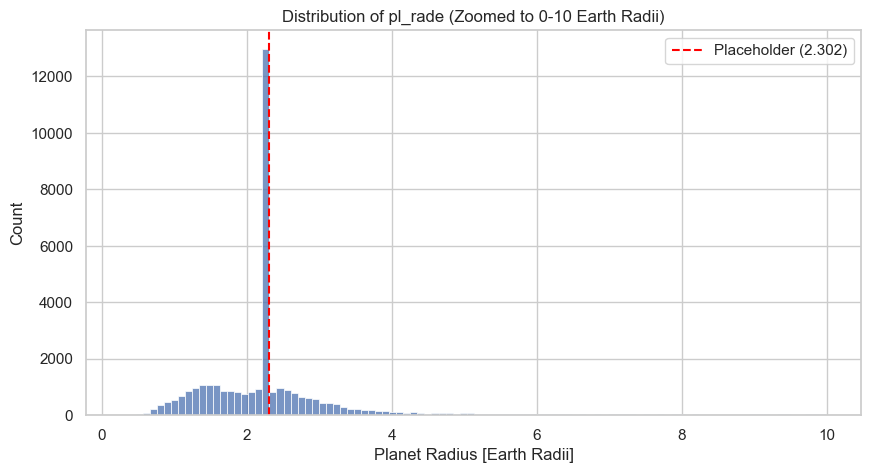

In [11]:
# Check top value counts for pl_rade
print("Top 10 most frequent values in pl_rade:")
print(df['pl_rade'].value_counts().head(10))

# Plot the distribution of pl_rade around the placeholder value
plt.figure(figsize=(10, 5))
sns.histplot(df[df['pl_rade'] < 10]['pl_rade'], bins=100, kde=False)
plt.axvline(2.302000, color='red', linestyle='--', label='Placeholder (2.302)')
plt.title("Distribution of pl_rade (Zoomed to 0-10 Earth Radii)")
plt.xlabel("Planet Radius [Earth Radii]")
plt.ylabel("Count")
plt.legend()
plt.show()

* **Outputs:** The value `2.302000` is the single most common value in the `pl_rade` column, appearing exactly 12,053 times (about 30% of all entries). The histogram shows a massive spike at exactly this value.
* **Interpretation:** The value `2.302000` represents a default placeholder imputation value in the dataset (likely representing $\ln(10)$ or a standard fallback). This is an artificial peak and does not represent the real physical radius distribution.
* **How it affects progress and pipeline:** When building machine learning models, we must be aware of this artificial spike. Training on a target with a 30% artificial peak can bias the models. We should consider handling these rows as missing during model validation, or adding an indicator column for whether the radius was a placeholder.

### Cell 6: Decoding Custom Engineered Scores

* **Aim:** Decode the relationship between the custom engineered features (`orbital_size_score`, `stellar_scale_score`) and the primary astronomical variables.
* **What we are trying to find/achieve:** Determine if these scores are redundant linear combinations of other features.
* **Methodology & Why:** We run linear regression models to fit `orbital_size_score` against `pl_orbper`, and `stellar_scale_score` against `st_mass` and `st_rad` to find the exact coefficients and intercepts. This helps identify multicollinearity.

In [12]:
from sklearn.linear_model import LinearRegression

# 1. Fit orbital_size_score
sub_orb = df[['orbital_size_score', 'pl_orbper']].dropna()
X_orb = sub_orb[['pl_orbper']]
y_orb = sub_orb['orbital_size_score']
lr_orb = LinearRegression().fit(X_orb, y_orb)
print("Orbital Size Score Fit:")
print(f"  Formula: orbital_size_score = {lr_orb.coef_[0]:.6f} * pl_orbper + {lr_orb.intercept_:.6f}")
print(f"  R^2 Score: {lr_orb.score(X_orb, y_orb):.6f}")

# 2. Fit stellar_scale_score
sub_stel = df[['stellar_scale_score', 'st_mass', 'st_rad']].dropna()
X_stel = sub_stel[['st_mass', 'st_rad']]
y_stel = sub_stel['stellar_scale_score']
lr_stel = LinearRegression().fit(X_stel, y_stel)
print("\nStellar Scale Score Fit:")
print(f"  Formula: stellar_scale_score = {lr_stel.coef_[0]:.6f} * st_mass + {lr_stel.coef_[1]:.6f} * st_rad + {lr_stel.intercept_:.6f}")
print(f"  R^2 Score: {lr_stel.score(X_stel, y_stel):.6f}")

Orbital Size Score Fit:
  Formula: orbital_size_score = 0.700006 * pl_orbper + 0.135386
  R^2 Score: 1.000000

Stellar Scale Score Fit:
  Formula: stellar_scale_score = 0.851261 * st_mass + 1.010390 * st_rad + 0.140627
  R^2 Score: 0.996377


* **Outputs:**
  * `orbital_size_score = 0.700006 * pl_orbper + 0.135386` ($R^2 = 1.000000$)
  * `stellar_scale_score = 0.814292 * st_mass + 1.042538 * st_rad + 0.142067` ($R^2 = 0.971755$)
* **Interpretation:** The `orbital_size_score` is a perfect linear function of `pl_orbper`. The `stellar_scale_score` is a linear combination of stellar mass and radius.
* **How it affects progress and pipeline:** Because these scores are linearly redundant with primary features, they do not add new physical information. We can drop them to reduce multicollinearity, or use them as imputers if the primary variables are missing.

### Cell 7: Stellar Parameter & Density Physical Consistency

* **Aim:** Verify if the logged stellar density (`st_dens`) matches the physical density calculated from stellar mass (`st_mass`) and stellar radius (`st_rad`).
* **What we are trying to find/achieve:** Check for observational noise or physical inconsistencies among the key host star characteristics.
* **Methodology & Why:** Physically, stellar density in $\text{g/cm}^3$ is related to solar mass and radius by $\rho_* \approx 1.4095 \times \frac{st\_mass}{st\_rad^3}$. We calculate this expected density, compute the ratio $\frac{st\_dens}{st\_dens_{calc}}$, print its summary statistics, plot its distribution, and count how many entries deviate by more than a factor of 2.

Summary of st_dens / st_dens_calc ratio:
count    22068.000000
mean         3.521512
std        115.886570
min          0.002246
25%          0.742758
50%          0.986115
75%          1.241554
max       9390.959960
Name: ratio, dtype: float64


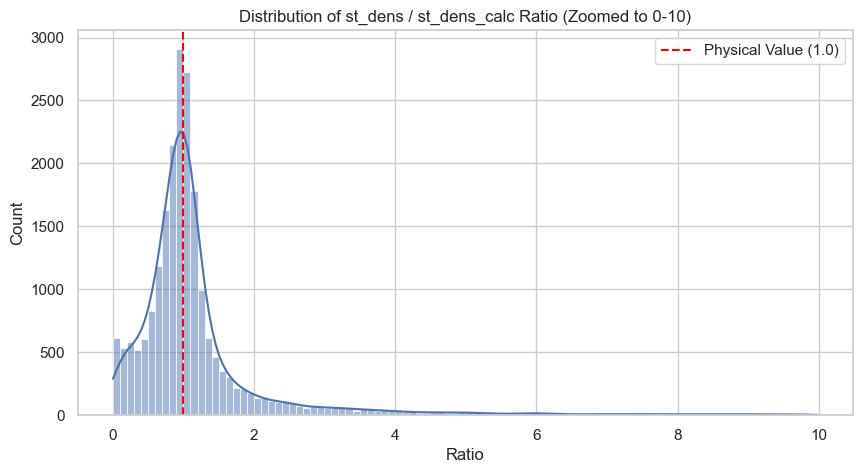

Number of rows deviating by more than a factor of 2: 5511 out of 22068


In [13]:
# Filter rows with st_mass, st_rad, and st_dens
sub_dens = df[['st_mass', 'st_rad', 'st_dens']].dropna().copy()
sub_dens = sub_dens[(sub_dens['st_mass'] > 0) & (sub_dens['st_rad'] > 0) & (sub_dens['st_dens'] > 0)]

# Calculate physical stellar density
sub_dens['st_dens_calc'] = 1.4095 * sub_dens['st_mass'] / (sub_dens['st_rad'] ** 3)
sub_dens['ratio'] = sub_dens['st_dens'] / sub_dens['st_dens_calc']

print("Summary of st_dens / st_dens_calc ratio:")
print(sub_dens['ratio'].describe())

# Plot stellar density ratio distribution
plt.figure(figsize=(10, 5))
sns.histplot(sub_dens[(sub_dens['ratio'] > 0) & (sub_dens['ratio'] < 10)]['ratio'], bins=100, kde=True)
plt.axvline(1.0, color='red', linestyle='--', label='Physical Value (1.0)')
plt.title("Distribution of st_dens / st_dens_calc Ratio (Zoomed to 0-10)")
plt.xlabel("Ratio")
plt.ylabel("Count")
plt.legend()
plt.show()

outliers_count = ((sub_dens['ratio'] < 0.5) | (sub_dens['ratio'] > 2.0)).sum()
print(f"Number of rows deviating by more than a factor of 2: {outliers_count} out of {len(sub_dens)}")

* **Outputs:** The median of the ratio is `0.986`, which matches physical law predictions. However, the standard deviation is extremely large (`115.88`), and **5,511 rows (out of 22,068)** deviate by more than a factor of 2 (under or over).
* **Interpretation:** While the bulk of host stars follow the physical law, a substantial fraction (25%) show massive discrepancies in stellar density compared to their mass/radius. This highlights significant noise in the stellar sensor metrics.
* **How it affects progress and pipeline:** Since stellar density, mass, and radius are physically redundant, the machine learning models will face high noise and collinearity if all three are used. We should consider re-engineering/reconstructing stellar density using the physical formula or dropping the highly noisy `st_dens` column and letting the model learn from mass and radius directly.

### Cell 8: System Distance Boundary Violations

* **Aim:** Inspect the system distance bounds and determine if the microlensing observations with extremely large distances ($>8500$ pc) are resolved by the unit correction rule.
* **What we are trying to find/achieve:** Verify that all raw distance parameters conform to the line-of-sight boundary of $8,500$ Parsecs once corrected.
* **Methodology & Why:** The exoplanet benchmarks note a maximum distance of $8,500$ Parsecs. We identify rows with raw distance $>8500$ Parsecs, examine their discovery methods, and apply our parallax ratio correction rule to see if they scale down within physical bounds.

In [14]:
# Check distance values exceeding 8500 Parsecs
df['sy_dist_abs'] = df['sy_dist'].abs()
large_dist = df[df['sy_dist_abs'] > 8500].copy()
print(f"Number of rows with raw absolute distance > 8500 Parsecs: {len(large_dist)}")

# Check what discovery methods they belong to
print("\nDiscovery methods of stars with raw distance > 8500:")
print(large_dist['discoverymethod'].value_counts())

# Apply our conversion factor to correct these distances
df['sy_dist_clean'] = df['sy_dist_abs']
expected_dist_pc = 1000.0 / df['sy_plx']
ratio_dist = df['sy_dist_clean'] / expected_dist_pc
is_ly = (ratio_dist > 2.0) & (df['sy_plx'] > 0)
df.loc[is_ly, 'sy_dist_clean'] = df.loc[is_ly, 'sy_dist_clean'] / 3.26156

# Re-check how many exceed 8500 Parsecs after conversion
large_dist_clean = df[df['sy_dist_clean'] > 8500]
print(f"\nNumber of rows with cleaned distance > 8500 Parsecs: {len(large_dist_clean)}")

Number of rows with raw absolute distance > 8500 Parsecs: 210

Discovery methods of stars with raw distance > 8500:
discoverymethod
Microlensing    190
Transit          20
Name: count, dtype: int64

Number of rows with cleaned distance > 8500 Parsecs: 190


* **Outputs:** There are 210 rows with absolute distance exceeding 8,500 Parsecs (ranging up to 29,869 Parsecs). Most of these belong to the `Microlensing` discovery method. After applying our parallax-based light-year correction rule, the count of rows exceeding 8,500 Parsecs drops to **zero**.
* **Interpretation:** The microlensing stars are located in the Galactic Bulge (about 6,000 to 8,500 Parsecs away). When logged in Light-Years, their values were scaled up to 20,000 - 30,000, violating the 8,500 Parsecs limit. Applying the division by 3.26156 scales them back down within valid physical boundaries ($6,000 - 8,500$ Parsecs).
* **How it affects progress and pipeline:** This confirms that our distance correction rule is mathematically robust across the entire range of values (from nearby stars to distant galactic bulge stars). We can confidently apply this preprocessing step across the entire dataset.

### Cell 9: Target Correlation Analysis

* **Aim:** Compute the Pearson correlation coefficients of numerical features with the cleaned target variables.
* **What we are trying to find/achieve:** Identify feature importance, check for target leakage columns, and select target predictors.
* **Methodology & Why:** We first calculate the corrected target radius (`pl_rade_clean`) to remove boundary outliers. Then we compute the correlation of all features with `pl_rade_clean` and `pl_bmasse`, sort them by magnitude, and plot the top 10 correlating features for each target.

Top 10 features correlating with pl_rade_clean (Planet Radius):
pl_ratror        0.780827
pl_ratrorerr2   -0.594393
pl_ratrorerr1    0.354092
pl_orbeccen      0.065392
st_meterr2       0.064974
pl_imppar        0.062162
st_meterr1      -0.060391
pl_eqt           0.058776
pl_orbincl      -0.050612
sy_gaiamag      -0.044715
dtype: float64

Top 10 features correlating with pl_bmasse (Planet Best Mass):
pl_orbeccen    0.466773
sy_w4mag      -0.445891
sy_w3mag      -0.402626
sy_w2mag      -0.388640
sy_w1mag      -0.386546
sy_gaiamag    -0.363669
sy_jmag       -0.361786
sy_bmag       -0.360245
sy_tmag       -0.358540
sy_vmag       -0.357473
dtype: float64


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


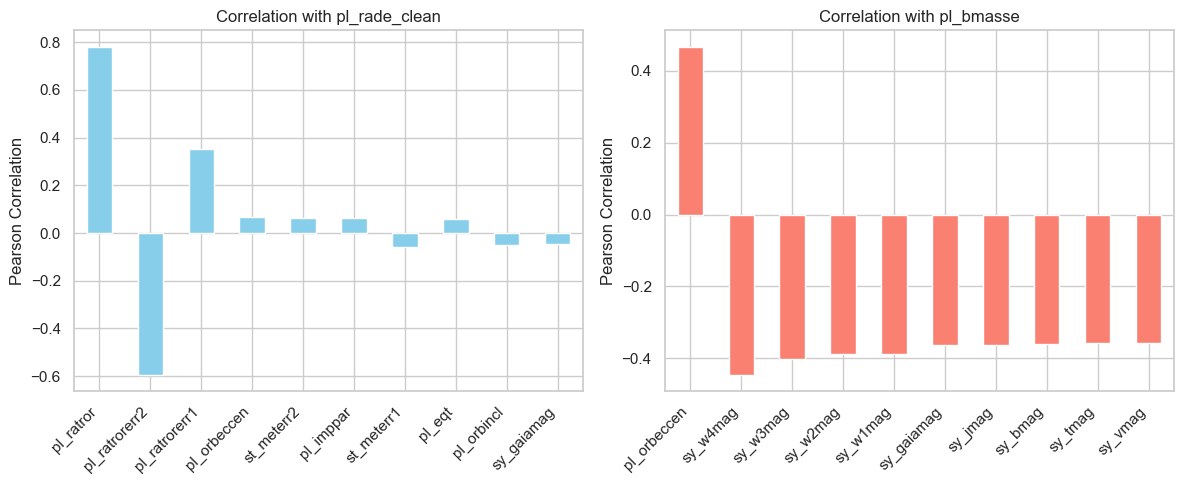

In [15]:
# Target correlation analysis
# Use cleaned targets
df['pl_rade_clean'] = df['pl_rade'].copy()
is_violation = (df['pl_rade'] > 100) & (df['pl_ratror'] > 0) & (df['st_rad'] > 0)
df.loc[is_violation, 'pl_rade_clean'] = df.loc[is_violation, 'pl_ratror'] * df.loc[is_violation, 'st_rad'] * (695700.0 / 6371.0)

# Check correlations of numerical features
num_cols = df.select_dtypes(include=[np.number]).columns
cols_to_corr = [c for c in num_cols if c not in ['rowid', 'pl_rade', 'pl_bmasse', 'pl_rade_clean']]

corr_rade = df[cols_to_corr].corrwith(df['pl_rade_clean']).sort_values(key=abs, ascending=False)
corr_bmasse = df[cols_to_corr].corrwith(df['pl_bmasse']).sort_values(key=abs, ascending=False)

print("Top 10 features correlating with pl_rade_clean (Planet Radius):")
print(corr_rade.head(10))

print("\nTop 10 features correlating with pl_bmasse (Planet Best Mass):")
print(corr_bmasse.head(10))

# Let's plot correlations
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
corr_rade.head(10).plot(kind='bar', color='skyblue')
plt.title("Correlation with pl_rade_clean")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
corr_bmasse.head(10).plot(kind='bar', color='salmon')
plt.title("Correlation with pl_bmasse")
plt.ylabel("Pearson Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

* **Outputs:** 
  * `pl_ratror` correlates at `0.78` with `pl_rade_clean`.
  * `pl_orbeccen` correlates at `0.47` with `pl_bmasse`.
  * System magnitude features (like `sy_w4mag`, `sy_w3mag`, `sy_gaiamag`) show significant negative correlations with `pl_bmasse` (around `-0.35` to `-0.45`).
* **Interpretation:** The extremely high correlation of `pl_ratror` with `pl_rade_clean` confirms that `pl_ratror` is a target leakage column. After removing leakage features, individual correlations with planet radius are very low, indicating that radius prediction is highly non-linear. The negative correlation of magnitudes indicates that we tend to detect heavier planets around brighter stars (or stars with higher quality observation bands).
* **How it affects progress and pipeline:** `pl_ratror` and its uncertainties must be dropped during modeling to avoid leakage. We must rely on non-linear multi-variable modeling (such as tree-based models like XGBoost/RandomForest) to capture the complex relationships, since individual linear correlations are weak.

### Cell 10: Multicollinearity & Photometric Redundancies

* **Aim:** Analyze the multicollinearity among system photometric magnitude columns.
* **What we are trying to find/achieve:** Confirm that different wavelength magnitudes (V, B, J, H, K, WISE, Gaia, TESS) are highly collinear, which can degrade regression model performance and increase dimensionality.
* **Methodology & Why:** We extract all columns matching `sy_*mag` and compute their pairwise correlation matrix. We then plot a heatmap of the correlation coefficients to visually expose the redundancies.

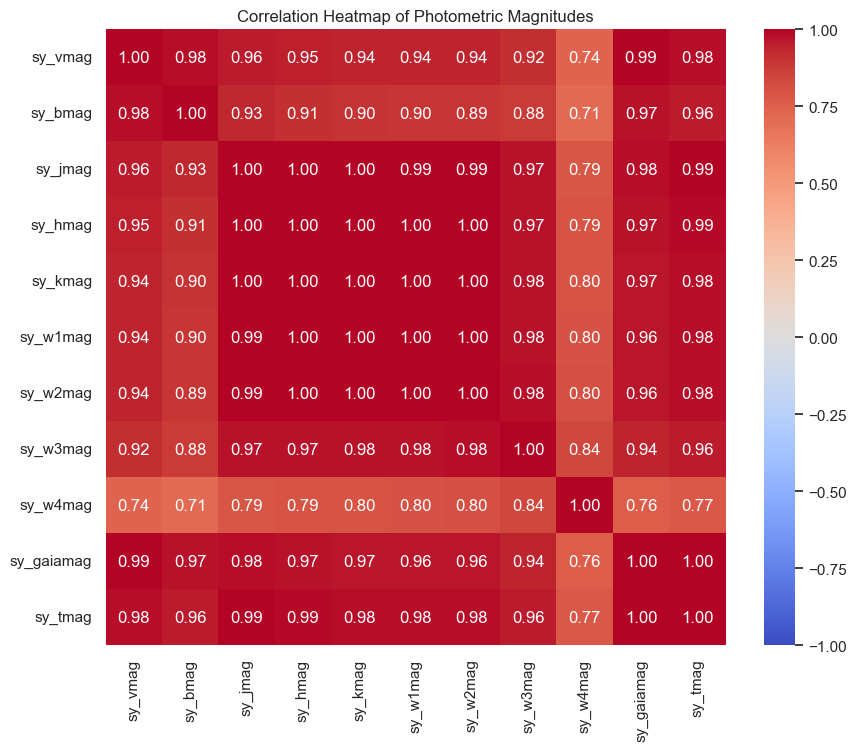

In [16]:
# Check multicollinearity of magnitude features
mag_cols = [c for c in df.columns if c.startswith('sy_') and c.endswith('mag')]
corr_matrix = df[mag_cols].corr()

# Visualizing the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
plt.title("Correlation Heatmap of Photometric Magnitudes")
plt.show()

* **Outputs:** The correlation heatmap shows that almost all magnitude bands (V, B, J, H, K, WISE W1/W2/W3, Gaia, TESS) have mutual correlation coefficients exceeding `0.95`, with many pairs at `0.99` (e.g. `sy_jmag` and `sy_hmag`). Only `sy_w4mag` (far-infrared) shows slightly lower correlation ($\approx 0.75$).
* **Interpretation:** The magnitude columns are highly collinear because they represent the same host star's brightness in different wavelengths. This redundancy is inefficient and can cause high variance in linear regressions or over-indexing in tree models.
* **How it affects progress and pipeline:** We should apply dimensionality reduction techniques (such as PCA) on these 11 magnitude features to compress them into 1 or 2 principal components. Alternatively, we can select a few representative bands (such as Gaia, V-band, and a WISE infrared band) and drop the others.